In [1]:
import json
import pandas as pd
import numpy as np

with open('ntrk1_variants_raw.json') as f:
    raw = json.load(f)

print(f"Loaded {len(raw)} raw variant records")
print(json.dumps(raw[0], indent=2)[:2000])

Loaded 1375 raw variant records
{
  "_id": "chr1:g.156851403C>T",
  "_score": 8.148894,
  "cadd": {
    "_license": "http://bit.ly/2TIuab9",
    "alt": "T",
    "anc": "C",
    "annotype": "CodingTranscript",
    "bstatistic": 640,
    "chmm": {
      "bivflnk": 0.0,
      "enh": 0.0,
      "enhbiv": 0.016,
      "het": 0.0,
      "quies": 0.11,
      "reprpc": 0.307,
      "reprpcwk": 0.496,
      "tssa": 0.0,
      "tssaflnk": 0.0,
      "tssbiv": 0.008,
      "tx": 0.0,
      "txflnk": 0.0,
      "txwk": 0.039,
      "znfrpts": 0.0
    },
    "chrom": 1,
    "consdetail": "missense",
    "consequence": "NON_SYNONYMOUS",
    "consscore": 7,
    "cpg": 0.08,
    "dna": {
      "helt": 2.0,
      "mgw": 0.55,
      "prot": -2.79,
      "roll": 0.39
    },
    "encode": {
      "exp": 287.7,
      "h3k27ac": 4.0,
      "h3k4me1": 11.72,
      "h3k4me3": 3.0,
      "nucleo": 0.7,
      "occ": 2,
      "p_val": {
        "comb": 2.29,
        "ctcf": 0.0,
        "dnas": 2.6,
        "fai

In [2]:
print(json.dumps(raw[0].get('clinvar', 'NO CLINVAR FIELD'), indent=2))

# Check a few more records too, since ClinVar structure can vary
for i in range(5):
    cv = raw[i].get('clinvar')
    print(f"\n--- Record {i} ---")
    print(json.dumps(cv, indent=2)[:500] if cv else "No clinvar data")

{
  "_license": "http://bit.ly/2SQdcI0",
  "gene": {
    "id": "4914",
    "symbol": "NTRK1"
  },
  "rcv": {
    "accession": "RCV002600014",
    "clinical_significance": "Likely benign",
    "conditions": {
      "identifiers": {
        "medgen": "C0020074",
        "mondo": "MONDO:0009746",
        "omim": "256800",
        "orphanet": "642"
      },
      "name": "Hereditary insensitivity to pain with anhidrosis (CIPA)",
      "synonyms": [
        "INSENSITIVITY TO PAIN, CONGENITAL, WITH ANHIDROSIS",
        "FAMILIAL DYSAUTONOMIA, TYPE II",
        "NEUROPATHY, CONGENITAL SENSORY, WITH ANHIDROSIS",
        "HSAN 4",
        "Familial dysautonomia, type 2",
        "HSAN Type IV",
        "hereditary sensory and autonomic neuropathy type 4",
        "Hereditary Sensory and Autonomic Neuropathy Type IV"
      ]
    },
    "last_evaluated": "2024-02-22",
    "number_submitters": 1,
    "origin": "germline",
    "preferred_name": "NM_002529.4(NTRK1):c.2360C>T (p.Ala787Val)",
    "rev

In [4]:
def get_gene_info(cadd):
    gene = cadd.get('gene')
    if gene is None:
        return {}
    if isinstance(gene, list):
        return gene[0] if gene else {}
    return gene

rows = []
for record in raw:
    cadd = record.get('cadd')
    if not cadd:
        continue

    rcvs = get_rcv_list(record)
    if not rcvs:
        continue
    sig_list = [r.get('clinical_significance', '') for r in rcvs]
    label = classify_significance(sig_list)
    if label is None:
        continue

    gene_info = get_gene_info(cadd)
    prot_info = gene_info.get('prot', {}) if isinstance(gene_info.get('prot'), dict) else {}
    cds_info = gene_info.get('cds', {}) if isinstance(gene_info.get('cds'), dict) else {}

    rows.append({
        'variant_id': record.get('_id'),
        'label': label,
        'clinical_significance': '; '.join(set(sig_list)),
        'consequence': cadd.get('consequence'),
        'consscore': cadd.get('consscore'),
        'cadd_phred': cadd.get('phred'),
        'grantham': cadd.get('grantham'),
        'gerp_rs': cadd.get('gerp', {}).get('rs') if isinstance(cadd.get('gerp'), dict) else None,
        'gerp_s': cadd.get('gerp', {}).get('s') if isinstance(cadd.get('gerp'), dict) else None,
        'protein_domain': prot_info.get('domain'),
        'rel_prot_pos': prot_info.get('rel_prot_pos'),
        'rel_cds_pos': cds_info.get('rel_cds_pos'),
        'exon': cadd.get('exon'),
        'fitcons': cadd.get('fitcons'),
    })

df = pd.DataFrame(rows)
print(f"Parsed {len(df)} labeled variants")
print(f"Pathogenic/Likely pathogenic: {(df['label']==1).sum()}")
print(f"Benign/Likely benign: {(df['label']==0).sum()}")
print(df.head(10))
print(df.dtypes)

Parsed 706 labeled variants
Pathogenic/Likely pathogenic: 99
Benign/Likely benign: 607
            variant_id  label  \
0  chr1:g.156851403C>T      0   
1  chr1:g.156834568T>C      0   
2  chr1:g.156838400C>A      0   
3  chr1:g.156838525G>C      0   
4  chr1:g.156848950G>A      0   
5  chr1:g.156849914G>A      1   
6  chr1:g.156850078C>T      0   
7  chr1:g.156838278G>A      1   
8  chr1:g.156838304C>T      0   
9  chr1:g.156844412T>C      0   

                             clinical_significance             consequence  \
0                                    Likely benign          NON_SYNONYMOUS   
1                                    Likely benign              SYNONYMOUS   
2                                    Likely benign              SYNONYMOUS   
3                                    Likely benign  [REGULATORY, INTRONIC]   
4                                    Likely benign              SYNONYMOUS   
5                                       Pathogenic          NON_SYNONYMOUS   
6  

In [5]:
def flatten_consscore(val):
    if isinstance(val, list):
        return max(val)
    return val

def flatten_consequence(val):
    if isinstance(val, list):
        # Prioritize the more severe consequence
        priority = ['STOP_GAINED', 'STOP_LOST', 'CANONICAL_SPLICE', 'SPLICE_SITE',
                    'NON_SYNONYMOUS', 'SYNONYMOUS', 'REGULATORY', 'INTRONIC']
        for p in priority:
            if p in val:
                return p
        return val[0]
    return val

df['consscore'] = df['consscore'].apply(flatten_consscore).astype(float)
df['consequence'] = df['consequence'].apply(flatten_consequence)

print(df['consequence'].value_counts())
print()
print(df.isnull().sum())

consequence
SYNONYMOUS          424
NON_SYNONYMOUS       98
INTRONIC             94
SPLICE_SITE          32
STOP_GAINED          28
REGULATORY           23
CANONICAL_SPLICE      5
DOWNSTREAM            2
Name: count, dtype: int64

variant_id                 0
label                      0
clinical_significance      0
consequence                0
consscore                  0
cadd_phred                 0
grantham                 608
gerp_rs                  153
gerp_s                     0
protein_domain           208
rel_prot_pos             148
rel_cds_pos              148
exon                     148
fitcons                    0
dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# One-hot encode categorical features
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['consequence', 'protein_domain'], dummy_na=True)

feature_cols = [c for c in df_model.columns if c not in
                ['variant_id', 'label', 'clinical_significance', 'exon']]

X = df_model[feature_cols]
y = df_model['label']

print(f"Features used: {feature_cols}")
print(f"Class balance: {y.value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',  # handles the 1:6 imbalance
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Pathogenic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Features used: ['consscore', 'cadd_phred', 'grantham', 'gerp_rs', 'gerp_s', 'rel_prot_pos', 'rel_cds_pos', 'fitcons', 'consequence_CANONICAL_SPLICE', 'consequence_DOWNSTREAM', 'consequence_INTRONIC', 'consequence_NON_SYNONYMOUS', 'consequence_REGULATORY', 'consequence_SPLICE_SITE', 'consequence_STOP_GAINED', 'consequence_SYNONYMOUS', 'consequence_nan', 'protein_domain_lcompl', 'protein_domain_ndomain', 'protein_domain_sigp', 'protein_domain_nan']
Class balance: {0: 607, 1: 99}

--- Classification Report ---
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98       152
  Pathogenic       0.91      0.84      0.88        25

    accuracy                           0.97       177
   macro avg       0.94      0.91      0.93       177
weighted avg       0.97      0.97      0.97       177

ROC-AUC: 0.987

Confusion Matrix:
[[150   2]
 [  4  21]]


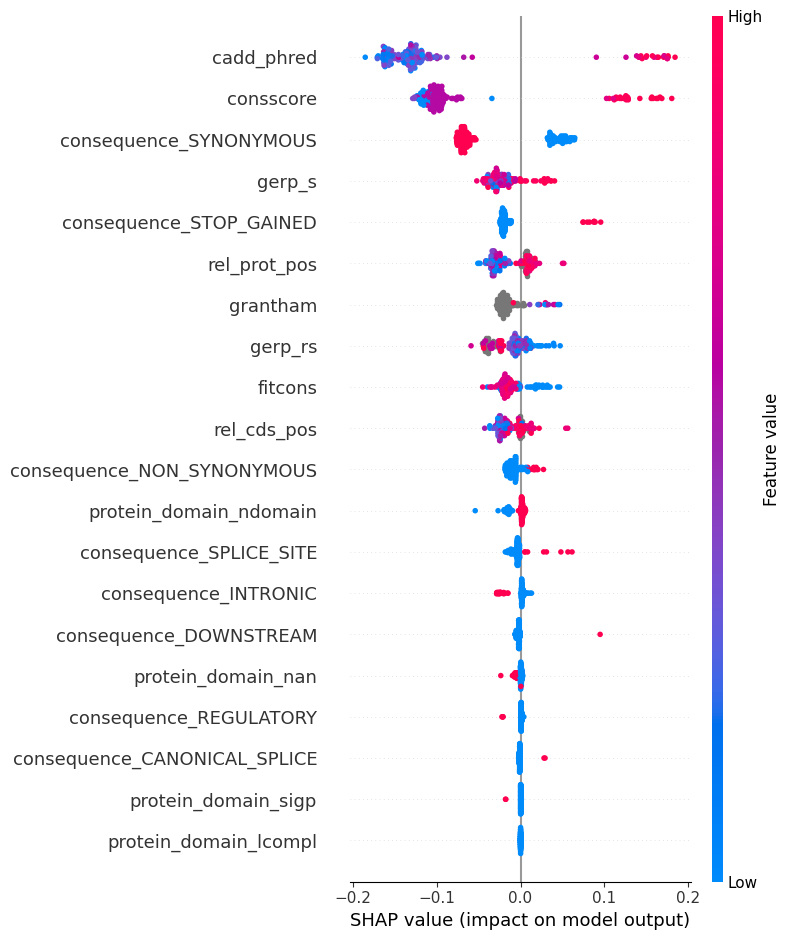

Top features by mean |SHAP value|:
                    feature  mean_abs_shap
1                cadd_phred       0.137731
0                 consscore       0.107272
15   consequence_SYNONYMOUS       0.058999
4                    gerp_s       0.026206
14  consequence_STOP_GAINED       0.023153
5              rel_prot_pos       0.020978
2                  grantham       0.020111
3                   gerp_rs       0.019562
7                   fitcons       0.017134
6               rel_cds_pos       0.014921


In [7]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values can be a list [class0, class1] or a single array depending on version
if isinstance(shap_values, list):
    shap_vals_pathogenic = shap_values[1]
else:
    shap_vals_pathogenic = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

# Summary plot: which features drive pathogenicity predictions overall
plt.figure()
shap.summary_plot(shap_vals_pathogenic, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top features by mean |SHAP value|:")
mean_abs_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_vals_pathogenic).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print(mean_abs_shap.head(10))